# **Exploratory Data Analysis from Gobis Suroboyo App Review**

### **3.y Analisis Data Eksploratif (Exploratory Data Analysis)**

Tahap Analisis Data Eksploratif (EDA) dilakukan untuk memahami karakteristik, pola, dan distribusi dataset ulasan Gobis Suroboyo secara mendalam sebelum masuk ke tahap pemodelan. Rangkaian analisis yang dilakukan meliputi:

1.  **Analisis Distribusi Skor:** Mengidentifikasi proporsi rating (1-5) untuk melihat dominasi kelas dan mendeteksi potensi ketidakseimbangan data (*data imbalance*) pada ulasan pengguna.
2.  **Analisis Tren Temporal:** Memetakan volume ulasan dan rata-rata skor secara tahunan. Langkah ini bertujuan untuk mengamati dinamika pertumbuhan data serta fluktuasi kepuasan pengguna dari waktu ke waktu secara kronologis.
3.  **Analisis Waktu Respon:** Menganalisis rentang waktu balasan developer terhadap ulasan pengguna (seperti <1 hari, 1-3 hari, dll).

### **Libraries**

In [1]:
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Load Dataset**

In [2]:
# Membaca dataset hasil scraping sebelumnya
df_gobis = pd.read_csv('rawdata_gobis.csv')

# Menampilkan 5 data teratas
df_gobis.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f90d5a4f-d920-406c-a079-91c3a0138479,Revan Ariello,https://play-lh.googleusercontent.com/a/ACg8oc...,supirnya kurang hati²,1,0,NaN,2026-04-23 16:55:11,NaN,NaN,NaN
1,f059dce5-de44-424a-bd87-f889564d8f26,Desy Chen,https://play-lh.googleusercontent.com/a/ACg8oc...,parahhh aplikasi. koneksi putus terus.. tolong...,1,0,NaN,2026-04-23 10:14:31,NaN,NaN,NaN
2,7a6008f5-0fbf-4d6d-8daf-c3942feef6bc,Aditya Rizaldy Bahren,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi thaekk🥺😭,1,0,11,2026-04-22 16:19:52,NaN,NaN,11
3,169a8f87-5f99-4c49-a152-17daceea4e59,oceanasky,https://play-lh.googleusercontent.com/a-/ALV-U...,TIDAK BISA LOGIN.,1,0,NaN,2026-04-22 07:53:42,NaN,NaN,NaN
4,153915b0-881f-455e-8e64-fa7510b79aa6,Alfnn Cndr,https://play-lh.googleusercontent.com/a-/ALV-U...,"perlu banyak perbaikan di aplikasi ini, inform...",1,0,11,2026-04-21 15:57:20,NaN,NaN,11


In [3]:
# Melihat informasi dataset (jumlah kolom, tipe data, missing value)
df_gobis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              1314 non-null   object 
 1   userName              1314 non-null   object 
 2   userImage             1314 non-null   object 
 3   content               1314 non-null   object 
 4   score                 1314 non-null   int64  
 5   thumbsUpCount         1314 non-null   int64  
 6   reviewCreatedVersion  1025 non-null   object 
 7   at                    1314 non-null   object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            1025 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 113.1+ KB


### **Data Cleaning (Pembersihan Awal)**

In [4]:
# Membuang duplikat data berdasarkan ID ulasan
df_gobis = df_gobis.drop_duplicates(subset=['reviewId'])

# Menangani Missing Values pada kolom yang krusial
df_gobis = df_gobis.dropna(subset=['content', 'score', 'at'])

# Konversi kolom tanggal ('at' dan 'repliedAt') menjadi tipe datetime agar bisa diolah grafiknya
df_gobis['at'] = pd.to_datetime(df_gobis['at'])
df_gobis['repliedAt'] = pd.to_datetime(df_gobis['repliedAt'], errors='coerce')

print(f"Jumlah data siap EDA: {len(df_gobis)} baris")

Jumlah data siap EDA: 1314 baris


### **1. Analisis Distribusi Skor (Rating)**

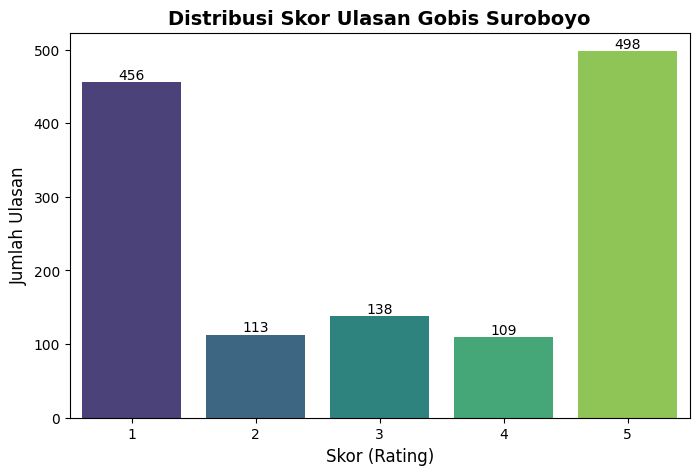

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_gobis, x='score', palette='viridis')
plt.title('Distribusi Skor Ulasan Gobis Suroboyo', fontsize=14, fontweight='bold')
plt.xlabel('Skor (Rating)', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

# Menambahkan label angka di atas diagram batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

### **2. Analisis Tren Temporal (Waktu)**

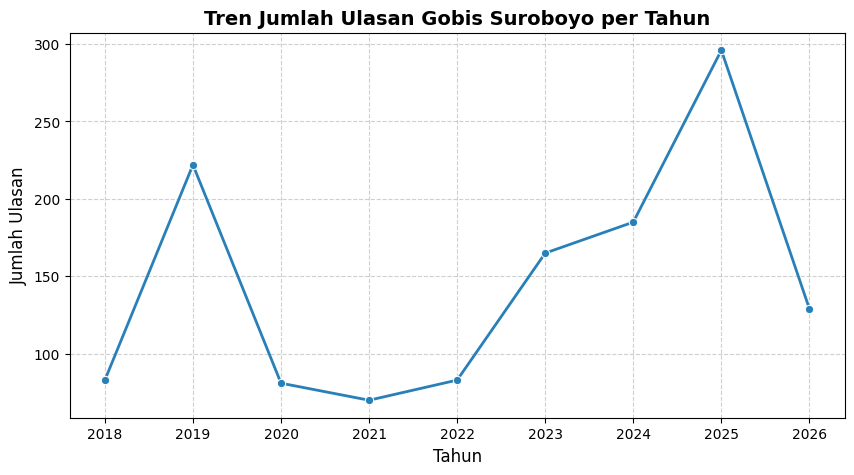

In [6]:
# Mengekstrak Tahun dari kolom 'at'
df_gobis['year'] = df_gobis['at'].dt.year

# Menghitung jumlah ulasan per tahun
trend_yearly = df_gobis.groupby('year').size()

plt.figure(figsize=(10, 5))
sns.lineplot(x=trend_yearly.index, y=trend_yearly.values, marker='o', color='#2980b9', linewidth=2)
plt.title('Tren Jumlah Ulasan Gobis Suroboyo per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(trend_yearly.index)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **3. Analisis Waktu Respon Developer**

Tabel Frekuensi Waktu Respon:


,count
response_category,
<1 hari,0.0
1–3 hari,0.0
3–7 hari,0.0
7–14 hari,0.0
14–30 hari,0.0
>30 hari,0.0


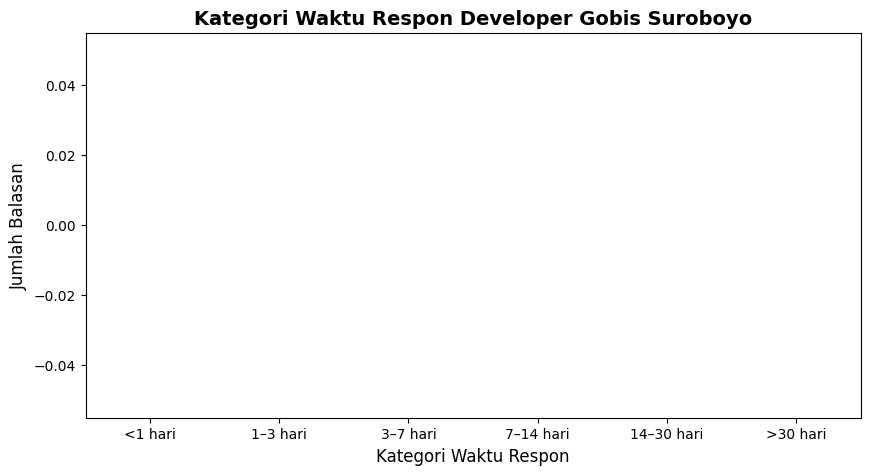

In [7]:
# Menghitung selisih hari antara ulasan dibuat ('at') dan dibalas ('repliedAt')
df_respon = df_gobis.dropna(subset=['repliedAt']).copy()
df_respon['response_time_days'] = (df_respon['repliedAt'] - df_respon['at']).dt.days

def categorize_response_time(days):
    if days < 1: return '<1 hari'
    elif 1 <= days <= 3: return '1–3 hari'
    elif 3 < days <= 7: return '3–7 hari'
    elif 7 < days <= 14: return '7–14 hari'
    elif 14 < days <= 30: return '14–30 hari'
    else: return '>30 hari'

df_respon['response_category'] = df_respon['response_time_days'].apply(categorize_response_time)

# Menghitung jumlah untuk setiap kategori (Menyamakan dengan tabel referensi Agoda)
kategori_order = ['<1 hari', '1–3 hari', '3–7 hari', '7–14 hari', '14–30 hari', '>30 hari']
response_counts = df_respon['response_category'].value_counts().reindex(kategori_order).fillna(0)

df_response_table = pd.DataFrame(response_counts)
df_response_table.columns = ['count']

print("Tabel Frekuensi Waktu Respon:")
display(df_response_table)

# Visualisasi Waktu Respon
plt.figure(figsize=(10, 5))
sns.barplot(x=response_counts.index, y=response_counts.values, palette='magma')
plt.title('Kategori Waktu Respon Developer Gobis Suroboyo', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Waktu Respon', fontsize=12)
plt.ylabel('Jumlah Balasan', fontsize=12)
plt.show()

### **Menyimpan Data yang Sudah Dibersihkan ke CSV**

In [8]:
# Menyimpan data yang sudah ditangani missing valuenya untuk tahap Prepocessing Teks selanjutnya
df_gobis.to_csv('eda_data_gobis.csv', index=False)
print("✅ File 'eda_data_gobis.csv' berhasil disimpan dan siap untuk Text Preprocessing!")

✅ File 'eda_data_gobis.csv' berhasil disimpan dan siap untuk Text Preprocessing!
